# 05b — LightGBM Global Model (Weekly)
## Same Architecture as 05a, Different Engine — Apples-to-Apples Comparison

**Purpose.** Train a single LightGBM regressor on the same weekly feature matrix
as 05a XGBoost, with the same global-model architecture. This pairing is the
core of the gradient-boosting comparison: both share Poisson regression, early
stopping, and the same evaluation pipeline.

**Input:** `weekly_features.csv` (engineered features × ~17,000 rows from notebook 03)

**Outputs:**
- `lightgbm_weekly_predictions.csv` — predictions on val + test sets
- `lightgbm_weekly_metrics.csv` — per-item metrics
- `lightgbm_weekly_summary.json` — overall summary
- `lightgbm_weekly_feature_importance.csv` — split + gain importance
- `models/lightgbm_weekly/model.txt` — single global model (FastAPI-ready)
- `models/lightgbm_weekly/manifest.json` — feature order + encoding maps

**Why LightGBM alongside XGBoost:**
- Different tree growth strategy (leaf-wise vs depth-wise) → different inductive bias
- Often faster to train, sometimes more accurate on tabular data
- Gives us a defensible head-to-head comparison for the soutenance
- Both use the same data, same target, same metrics — so any difference is the algorithm

---


## 1. Setup


In [1]:
!pip install lightgbm --quiet



[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import os
import json
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

DATASETS_DIR = '../../datasets'
MODELS_DIR = '../../models/lightgbm'
os.makedirs(MODELS_DIR, exist_ok=True)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['font.size'] = 10

print(f"LightGBM version: {lgb.__version__}")
print(f"Working directory: {os.getcwd()}")
print(f"Models will be saved to: {os.path.abspath(MODELS_DIR)}")


## 2. Load weekly feature matrix


In [ ]:
# Load the weekly feature matrix from notebook 03
# (Filenames match what notebook 03 actually saves)
df = pd.read_csv(os.path.join(DATASETS_DIR, 'forecasting_features_weekly.csv'),
                 parse_dates=['week_start'])

# Auxiliary files produced by notebook 03
try:
    with open(os.path.join(DATASETS_DIR, 'feature_lists_weekly.json')) as f:
        feature_config = json.load(f)
    feature_cols = feature_config['tree_features']
    target_col = feature_config['target']
except FileNotFoundError:
    # Fallback: derive feature list automatically.
    # META matches notebook 03's meta_cols definition exactly.
    META = {'week_start', 'item_name', 'item_id', 'section', 'category',
            'holiday_type', 'split', 'quantity'}
    feature_cols = [c for c in df.columns
                    if c not in META
                    and df[c].dtype in ['int64', 'float64', 'int32', 'float32']]
    target_col = 'quantity'
    print("(feature_lists_weekly.json not found — derived features automatically)")

# Encoding maps (for FastAPI inference reconstruction)
try:
    with open(os.path.join(DATASETS_DIR, 'encoding_maps_weekly.json')) as f:
        encoding_maps = json.load(f)
except FileNotFoundError:
    encoding_maps = {}

print(f"Loaded: {len(df):,} rows × {len(df.columns)} columns")
print(f"Tree features: {len(feature_cols)}")
print(f"Target: {target_col}")
print(f"\nSplit distribution:")
print(df['split'].value_counts())
print(f"\nDate ranges:")
for split in ['train', 'val', 'test']:
    sub = df[df['split'] == split]
    if len(sub) > 0:
        print(f"  {split:5s}: {sub['week_start'].min().date()} → {sub['week_start'].max().date()}  ({len(sub):,} rows, {sub['week_start'].nunique()} weeks)")


Loaded: 18,056 rows × 93 columns
Tree features: 85
Target: quantity

Split distribution:
train    11712
test      4758
val       1586
Name: split, dtype: int64

Date ranges:
  train: 2023-02-28 → 2024-12-24  (11,712 rows, 96 weeks)
  val  : 2024-12-31 → 2025-03-25  (1,586 rows, 13 weeks)
  test : 2025-04-01 → 2025-12-23  (4,758 rows, 39 weeks)


## 3. Prepare train / val / test sets


In [ ]:
train_df = df[df['split'] == 'train']
val_df = df[df['split'] == 'val']
test_df = df[df['split'] == 'test']

# Same features-to-remove rule as 05a — keep the comparison apples-to-apples
features_to_remove = ['item_encoded', 'weeks_since_start']
features_to_remove = [f for f in features_to_remove if f in feature_cols]
feature_cols = [c for c in feature_cols if c not in features_to_remove]
if features_to_remove:
    print(f"Features removed (same as 05a): {features_to_remove}")
print(f"Remaining features: {len(feature_cols)}")

X_train = train_df[feature_cols].values
y_train = train_df[target_col].values
X_val = val_df[feature_cols].values
y_val = val_df[target_col].values
X_test = test_df[feature_cols].values
y_test = test_df[target_col].values

train_ids = train_df[['week_start', 'item_name']].reset_index(drop=True)
val_ids = val_df[['week_start', 'item_name', 'section', 'category']].reset_index(drop=True)
test_ids = test_df[['week_start', 'item_name', 'section', 'category']].reset_index(drop=True)

print(f"\nTrain: {X_train.shape}  →  y range [{y_train.min():.0f}, {y_train.max():.0f}]  mean={y_train.mean():.2f}")
print(f"Val:   {X_val.shape}    →  y range [{y_val.min():.0f}, {y_val.max():.0f}]  mean={y_val.mean():.2f}")
print(f"Test:  {X_test.shape}   →  y range [{y_test.min():.0f}, {y_test.max():.0f}]  mean={y_test.mean():.2f}")

# LightGBM Datasets
train_data = lgb.Dataset(X_train, label=y_train, feature_name=feature_cols)
val_data = lgb.Dataset(X_val, label=y_val, feature_name=feature_cols, reference=train_data)
print("\n✓ LightGBM Dataset conversion complete")


Features removed (same as 05a): ['weeks_since_start']
Remaining features: 84

Train: (11712, 84)  →  y range [0, 43]  mean=9.13
Val:   (1586, 84)    →  y range [0, 37]  mean=7.73
Test:  (4758, 84)   →  y range [0, 39]  mean=10.22

✓ LightGBM Dataset conversion complete


## 4. Metric functions (same as 04a/04b/05a)


In [ ]:
def compute_metrics(actual, predicted, train_actual=None):
    """WAPE, MAE, RMSE, R², MAPE, sMAPE, MASE, Bias."""
    actual = np.asarray(actual, dtype=float)
    predicted = np.asarray(predicted, dtype=float)
    errors = actual - predicted
    abs_errors = np.abs(errors)

    mae = abs_errors.mean()
    rmse = np.sqrt((errors**2).mean())
    bias = errors.mean()

    nonzero = actual > 0
    mape = (abs_errors[nonzero] / actual[nonzero]).mean() if nonzero.sum() > 0 else np.nan

    denom = (np.abs(actual) + np.abs(predicted)) / 2
    smape_mask = denom > 0
    smape = (abs_errors[smape_mask] / denom[smape_mask]).mean() if smape_mask.sum() > 0 else np.nan

    actual_sum = actual.sum()
    wape = abs_errors.sum() / actual_sum if actual_sum > 0 else np.inf

    ss_res = (errors**2).sum()
    ss_tot = ((actual - actual.mean())**2).sum()
    r2 = 1 - ss_res / ss_tot if ss_tot > 0 else 0

    mase = np.nan
    if train_actual is not None and len(train_actual) > 52:
        naive_errors = np.abs(train_actual[52:] - train_actual[:-52])
        mae_naive = naive_errors.mean()
        if mae_naive > 0:
            mase = mae / mae_naive

    return {'mae': mae, 'rmse': rmse, 'mape': mape, 'smape': smape,
            'wape': wape, 'mase': mase, 'r2': r2, 'bias': bias}

print("Metric function ready: identical to 04a/04b/05a for fair comparison")


Metric function ready: identical to 04a/04b/05a for fair comparison


## 5. Train LightGBM with live loss tracking

**Hyperparameters paired with 05a XGBoost** for fair comparison:
- `poisson` objective (matches XGBoost's `count:poisson`)
- `num_leaves=31` (LightGBM's default, comparable to XGBoost's max_depth=6 → 2^6=64 leaves max)
- `learning_rate=0.05` (matches 05a)
- `feature_fraction=0.85` + `bagging_fraction=0.85` (matches 05a's colsample/subsample)
- `min_child_samples=20` (similar regularization role to XGBoost's `min_child_weight=3`)


In [ ]:
params = {
    'objective': 'poisson',
    'metric': ['mae', 'rmse'],
    'learning_rate': 0.05,
    'num_leaves': 31,
    'max_depth': -1,           # let num_leaves control complexity
    'feature_fraction': 0.85,
    'bagging_fraction': 0.85,
    'bagging_freq': 5,
    'min_child_samples': 20,
    'lambda_l2': 1.0,
    'verbose': -1,
    'seed': 42,
}

evals_result = {}
print("=" * 60)
print("LIGHTGBM TRAINING — LIVE BOOSTING ROUNDS (weekly)")
print("=" * 60)
print()

start_time = time.time()
model = lgb.train(
    params,
    train_data,
    num_boost_round=2000,
    valid_sets=[train_data, val_data],
    valid_names=['train', 'val'],
    callbacks=[
        lgb.early_stopping(stopping_rounds=50),
        lgb.log_evaluation(period=50),
        lgb.record_evaluation(evals_result),
    ],
)
training_time = time.time() - start_time

best_iter = model.best_iteration
best_score = model.best_score['val']['l1']  # MAE

print(f"\n{'='*60}")
print(f"✓ Training complete: {training_time:.1f}s")
print(f"✓ Best iteration:    {best_iter}")
print(f"✓ Best val MAE:      {best_score:.4f}")
print(f"{'='*60}")


LIGHTGBM TRAINING — LIVE BOOSTING ROUNDS (weekly)

Training until validation scores don't improve for 50 rounds
[50]	train's l1: 2.72119	train's rmse: 3.49348	val's l1: 2.72293	val's rmse: 3.41067
[100]	train's l1: 2.43499	train's rmse: 3.13665	val's l1: 2.42493	val's rmse: 3.10016
[150]	train's l1: 2.33832	train's rmse: 3.01184	val's l1: 2.37501	val's rmse: 3.05525
[200]	train's l1: 2.27029	train's rmse: 2.9223	val's l1: 2.36899	val's rmse: 3.05364
[250]	train's l1: 2.21212	train's rmse: 2.84208	val's l1: 2.36723	val's rmse: 3.05117
[300]	train's l1: 2.16182	train's rmse: 2.77633	val's l1: 2.36772	val's rmse: 3.05068
Early stopping, best iteration is:
[281]	train's l1: 2.17605	train's rmse: 2.79218	val's l1: 2.36604	val's rmse: 3.04867

✓ Training complete: 0.9s
✓ Best iteration:    281
✓ Best val MAE:      2.3660


## 6. Learning curves


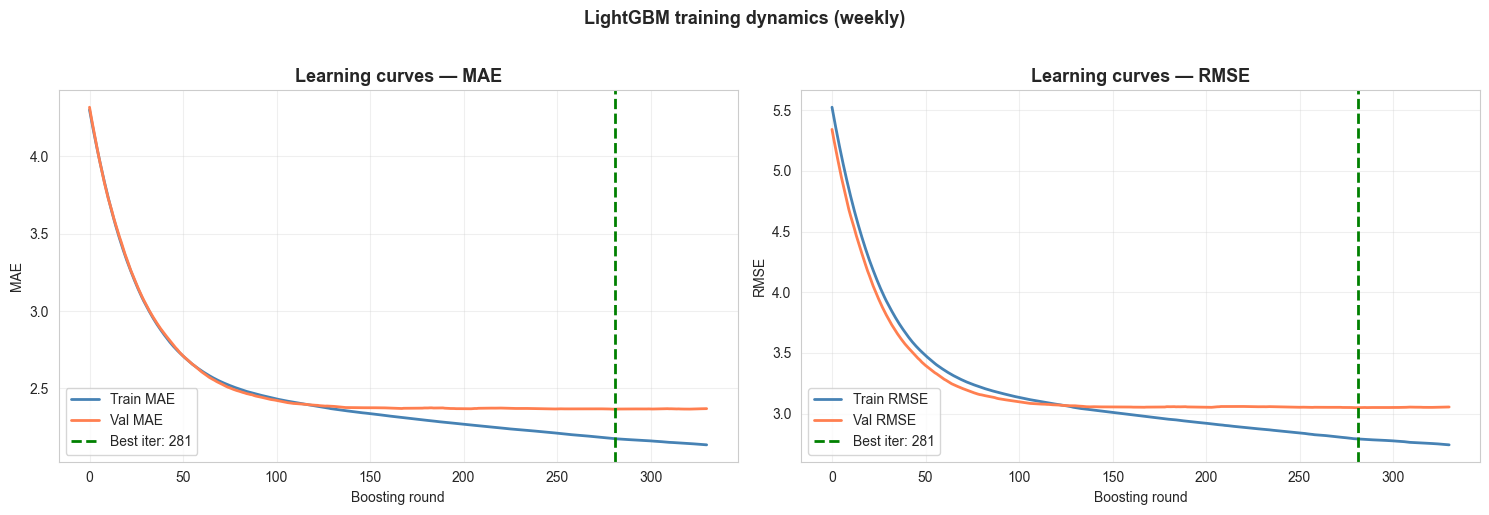


Train-val MAE gap at best iteration: 0.1914
  Train MAE: 2.1751
  Val MAE:   2.3665
  → Small gap, healthy fit


In [ ]:
train_mae = evals_result['train']['l1']
val_mae = evals_result['val']['l1']
train_rmse = evals_result['train']['rmse']
val_rmse = evals_result['val']['rmse']

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ax = axes[0]
ax.plot(train_mae, label='Train MAE', color='steelblue', linewidth=2)
ax.plot(val_mae, label='Val MAE', color='coral', linewidth=2)
ax.axvline(best_iter, color='green', linestyle='--', linewidth=2,
           label=f'Best iter: {best_iter}')
ax.set_xlabel('Boosting round')
ax.set_ylabel('MAE')
ax.set_title('Learning curves — MAE')
ax.legend(); ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(train_rmse, label='Train RMSE', color='steelblue', linewidth=2)
ax.plot(val_rmse, label='Val RMSE', color='coral', linewidth=2)
ax.axvline(best_iter, color='green', linestyle='--', linewidth=2,
           label=f'Best iter: {best_iter}')
ax.set_xlabel('Boosting round')
ax.set_ylabel('RMSE')
ax.set_title('Learning curves — RMSE')
ax.legend(); ax.grid(alpha=0.3)

plt.suptitle('LightGBM training dynamics (weekly)', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('lightgbm_weekly_learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()

final_gap = val_mae[best_iter] - train_mae[best_iter]
print(f"\nTrain-val MAE gap at best iteration: {final_gap:.4f}")
print(f"  Train MAE: {train_mae[best_iter]:.4f}")
print(f"  Val MAE:   {val_mae[best_iter]:.4f}")
if final_gap < 0.5:
    print(f"  → Small gap, healthy fit")
elif final_gap < 1.5:
    print(f"  → Moderate gap, mild overfitting (normal for tree models on weekly)")
else:
    print(f"  → Large gap, consider stronger regularization")


## 7. Generate predictions


In [ ]:
val_preds = model.predict(X_val, num_iteration=best_iter)
test_preds = model.predict(X_test, num_iteration=best_iter)

val_preds = np.clip(val_preds, 0, None)
test_preds = np.clip(test_preds, 0, None)

val_pred_df = val_ids.copy()
val_pred_df['actual'] = y_val
val_pred_df['predicted'] = val_preds
val_pred_df['split'] = 'val'

test_pred_df = test_ids.copy()
test_pred_df['actual'] = y_test
test_pred_df['predicted'] = test_preds
test_pred_df['split'] = 'test'

predictions_df = pd.concat([val_pred_df, test_pred_df], ignore_index=True)
predictions_df = predictions_df.rename(columns={'week_start': 'ds'})

print(f"Predictions generated:")
print(f"  Val:  {len(val_pred_df):,} rows")
print(f"  Test: {len(test_pred_df):,} rows")
print(f"  Total: {len(predictions_df):,} rows")


Predictions generated:
  Val:  1,586 rows
  Test: 4,758 rows
  Total: 6,344 rows


## 8. Naive baselines


In [ ]:
df_orig = pd.read_csv(os.path.join(DATASETS_DIR, 'weekly_item_demand.csv'),
                      parse_dates=['week_start'])

TRAIN_END_W = pd.Timestamp('2024-12-30')
VAL_END_W = pd.Timestamp('2025-03-31')
df_orig['split'] = 'train'
df_orig.loc[df_orig['week_start'] > TRAIN_END_W, 'split'] = 'val'
df_orig.loc[df_orig['week_start'] > VAL_END_W, 'split'] = 'test'

items = sorted(df_orig['item_name'].unique())
forecast_dates = sorted(df_orig[df_orig['split'].isin(['val', 'test'])]['week_start'].unique())
n_forecast = len(forecast_dates)

naive_results = {'seasonal_naive': [], 'mean': [], 'last_value': []}

for item in items:
    item_train = df_orig[(df_orig['item_name'] == item) & (df_orig['split'] == 'train')].sort_values('week_start')
    item_actual = df_orig[(df_orig['item_name'] == item) & (df_orig['split'].isin(['val', 'test']))].sort_values('week_start')

    train_qty = item_train['quantity'].values
    actual_qty = item_actual['quantity'].values

    if len(train_qty) == 0 or len(actual_qty) == 0:
        continue

    if len(train_qty) >= 52:
        last_year = train_qty[-52:]
        seasonal_pred = np.tile(last_year, n_forecast // 52 + 1)[:n_forecast]
    else:
        seasonal_pred = np.full(n_forecast, train_qty[-1])
    mean_pred = np.full(n_forecast, train_qty.mean())
    last_pred = np.full(n_forecast, train_qty[-1])

    for name, pred in [('seasonal_naive', seasonal_pred), ('mean', mean_pred), ('last_value', last_pred)]:
        for split in ['val', 'test']:
            split_mask = item_actual['split'].values == split
            if split_mask.sum() > 0:
                actual_split = actual_qty[split_mask]
                pred_aligned = pred[:len(actual_qty)]
                m = compute_metrics(actual_split, pred_aligned[split_mask], train_qty)
                m['item_name'] = item
                m['split'] = split
                naive_results[name].append(m)

naive_dfs = {k: pd.DataFrame(v) for k, v in naive_results.items()}
print("Naive baselines computed (seasonal_naive uses lag-52 for weekly yearly seasonality)")


Naive baselines computed (seasonal_naive uses lag-52 for weekly yearly seasonality)


## 9. Overall metrics — LightGBM vs naive baselines


LIGHTGBM OVERALL — vs naive baselines (weekly)
         Model Split    MAE   RMSE   WAPE  sMAPE      R²    Bias
seasonal_naive   val 3.2163 4.0140 0.4684 0.4949 -0.9064 -0.0095
seasonal_naive  test 3.5557 4.4877 0.3882 0.4185 -0.8228  0.4985
          mean   val 3.1434 3.7372 0.4724 0.4529 -0.6884 -1.2703
          mean  test 2.8912 3.7003 0.3087 0.3256 -0.1592  1.2239
    last_value   val 4.3134 4.9618 0.6270 0.5557 -2.4877 -2.4912
    last_value  test 4.1564 4.9449 0.4593 0.4770 -1.4437  0.0029
      lightgbm   val 2.3660 3.0487 0.3061 0.3744  0.6614 -0.3490
      lightgbm  test 2.6755 3.4983 0.2617 0.3059  0.6681  0.2804


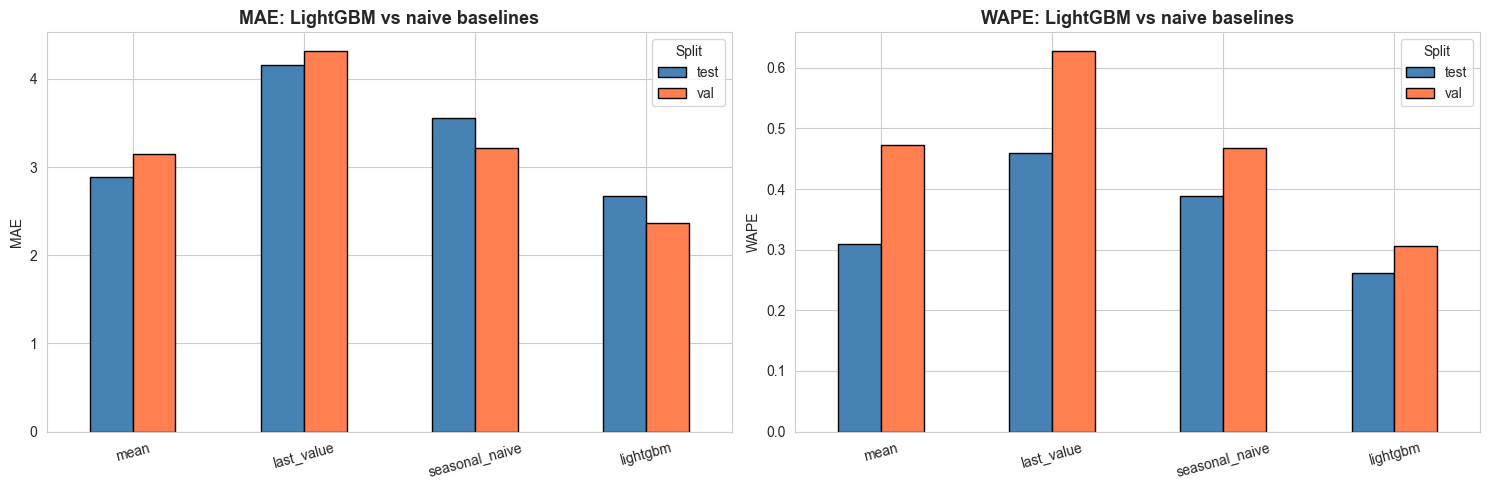

In [ ]:
comparison_rows = []

for name, df_n in naive_dfs.items():
    for split in ['val', 'test']:
        sub = df_n[df_n['split'] == split]
        comparison_rows.append({
            'Model': name, 'Split': split,
            'MAE': sub['mae'].mean(), 'RMSE': sub['rmse'].mean(),
            'WAPE': sub['wape'].mean(), 'sMAPE': sub['smape'].mean(),
            'R²': sub['r2'].mean(), 'Bias': sub['bias'].mean(),
        })

for split in ['val', 'test']:
    sp = predictions_df[predictions_df['split'] == split]
    agg = compute_metrics(sp['actual'].values, sp['predicted'].values)
    comparison_rows.append({
        'Model': 'lightgbm', 'Split': split,
        'MAE': agg['mae'], 'RMSE': agg['rmse'], 'WAPE': agg['wape'],
        'sMAPE': agg['smape'], 'R²': agg['r2'], 'Bias': agg['bias'],
    })

comparison_df = pd.DataFrame(comparison_rows)
print("=" * 80)
print("LIGHTGBM OVERALL — vs naive baselines (weekly)")
print("=" * 80)
print(comparison_df.to_string(index=False, float_format='%.4f'))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, metric in zip(axes, ['MAE', 'WAPE']):
    pivot = comparison_df.pivot(index='Model', columns='Split', values=metric)
    pivot = pivot.reindex(['mean', 'last_value', 'seasonal_naive', 'lightgbm'])
    pivot.plot(kind='bar', ax=ax, color=['steelblue', 'coral'], edgecolor='black')
    ax.set_title(f'{metric}: LightGBM vs naive baselines')
    ax.set_ylabel(metric); ax.set_xlabel('')
    ax.legend(title='Split'); ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('lightgbm_weekly_vs_baselines.png', dpi=150, bbox_inches='tight')
plt.show()


## 10. Per-item metrics


In [ ]:
per_item_metrics = []

train_data_dict = {}
for item in items:
    train_data_dict[item] = df_orig[
        (df_orig['item_name'] == item) & (df_orig['split'] == 'train')
    ]['quantity'].values

for split in ['val', 'test']:
    split_pred = predictions_df[predictions_df['split'] == split]
    for item in items:
        item_pred = split_pred[split_pred['item_name'] == item]
        if len(item_pred) > 0:
            m = compute_metrics(
                item_pred['actual'].values,
                item_pred['predicted'].values,
                train_data_dict[item]
            )
            m['item_name'] = item
            m['split'] = split
            m['n_predictions'] = len(item_pred)
            per_item_metrics.append(m)

metrics_df = pd.DataFrame(per_item_metrics)
print(f"Per-item metrics computed: {len(metrics_df)} rows ({metrics_df['item_name'].nunique()} items × {metrics_df['split'].nunique()} splits)")


Per-item metrics computed: 244 rows (122 items × 2 splits)


## 11. Per-section evaluation


LIGHTGBM — Per-section metrics (weekly)
      section split  n_items    mae   rmse   wape  smape      r2    bias
     American  test       21 3.0209 3.7766 0.2649 0.2801 -0.0373  0.3901
     American   val       21 3.0069 3.7114 0.3414 0.3587 -0.0104 -0.2293
         Cafe  test       17 3.1283 3.9950 0.2358 0.2438  0.1154  0.6522
         Cafe   val       17 2.4170 2.9083 0.2778 0.3283  0.4184  0.1787
Healthy_Vegan  test       12 2.4497 3.0885 0.3199 0.3441 -0.0347  0.3971
Healthy_Vegan   val       12 1.6868 2.1275 0.3503 0.3892  0.1114 -0.5644
      Italian  test       22 2.5699 3.2559 0.2929 0.3081  0.0533  0.1413
      Italian   val       22 2.2686 2.7185 0.3918 0.3916  0.0025 -0.6045
     Japanese  test       16 2.6886 3.3531 0.3035 0.3177 -0.0820  0.1706
     Japanese   val       16 2.3287 2.7723 0.3902 0.3848 -0.2235 -0.8422
      Mexican  test       19 2.5697 3.2259 0.3058 0.3173 -0.0264  0.0640
      Mexican   val       19 2.4105 2.9548 0.3449 0.3587  0.0080 -0.3194
   Steakhou

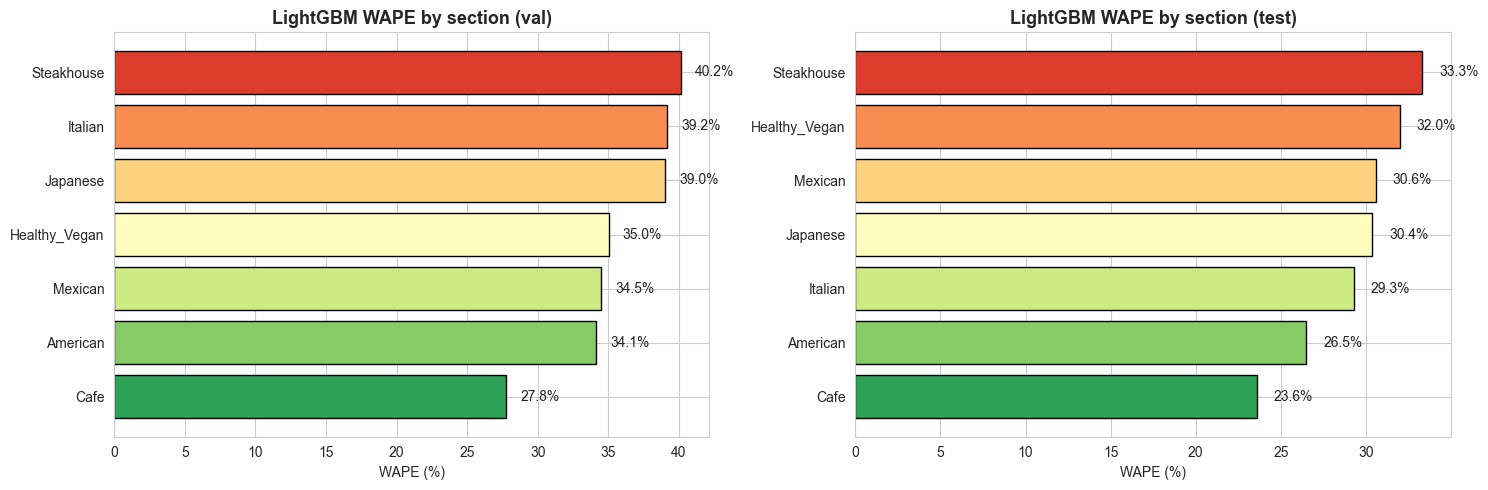

In [ ]:
section_map = df_orig[['item_name', 'section', 'category']].drop_duplicates().reset_index(drop=True)
metrics_with_section = metrics_df.merge(section_map, on='item_name')

section_results = metrics_with_section.groupby(['section', 'split']).agg(
    n_items=('item_name', 'nunique'),
    mae=('mae', 'mean'),
    rmse=('rmse', 'mean'),
    wape=('wape', 'mean'),
    smape=('smape', 'mean'),
    r2=('r2', 'mean'),
    bias=('bias', 'mean'),
).reset_index()

print("=" * 70)
print("LIGHTGBM — Per-section metrics (weekly)")
print("=" * 70)
print(section_results.to_string(index=False, float_format='%.4f'))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, split in zip(axes, ['val', 'test']):
    sec_data = section_results[section_results['split'] == split].sort_values('wape')
    bars = ax.barh(sec_data['section'], sec_data['wape']*100,
                   color=sns.color_palette('RdYlGn_r', len(sec_data)),
                   edgecolor='black')
    ax.set_title(f'LightGBM WAPE by section ({split})')
    ax.set_xlabel('WAPE (%)')
    for bar, val in zip(bars, sec_data['wape']*100):
        ax.text(val + 1, bar.get_y() + bar.get_height()/2,
                f'{val:.1f}%', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('lightgbm_weekly_per_section.png', dpi=150, bbox_inches='tight')
plt.show()


## 12. Per-volume-tier evaluation


LIGHTGBM — Performance by volume tier (weekly)
     volume_tier split  n_items    mae   wape  smape      r2
     Low (<7/wk)  test       46 2.0020 0.3572 0.3818 -0.0069
     Low (<7/wk)   val       46 1.8133 0.4481 0.4652 -0.0695
Medium (7-35/wk)  test       76 3.0831 0.2511 0.2600  0.0164
Medium (7-35/wk)   val       76 2.7006 0.3016 0.3194  0.0892


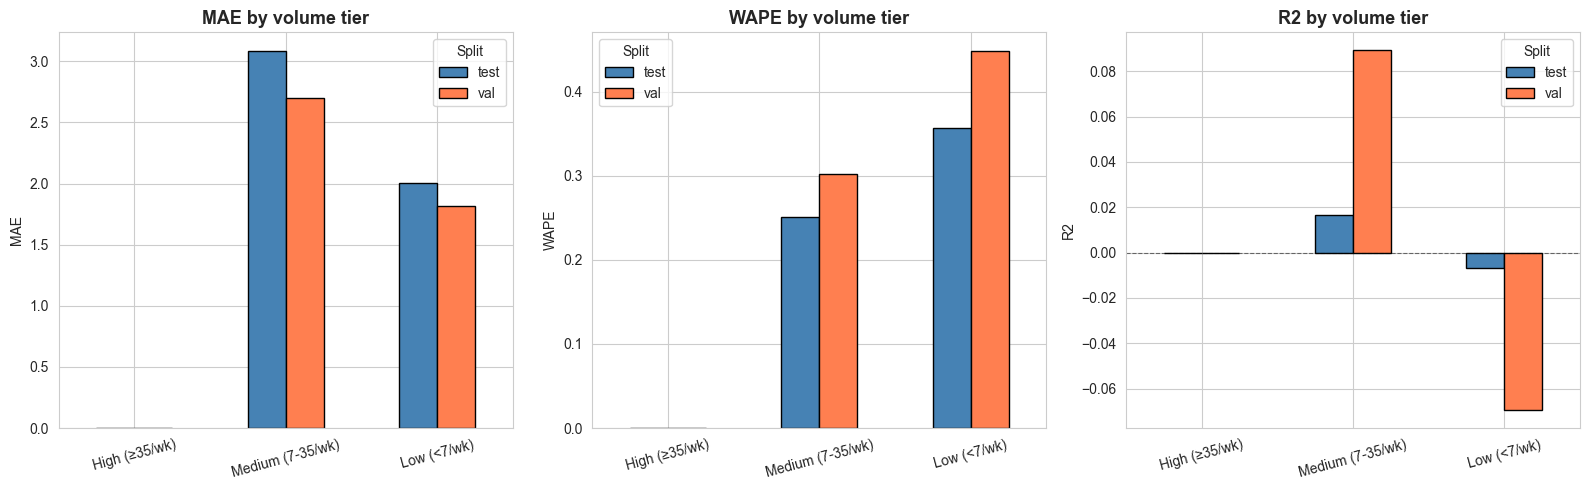

In [ ]:
item_volume = df_orig[df_orig['split']=='train'].groupby('item_name')['quantity'].mean().sort_values(ascending=False)

def assign_tier(avg):
    if avg >= 35: return 'High (≥35/wk)'
    elif avg >= 7: return 'Medium (7-35/wk)'
    else: return 'Low (<7/wk)'

item_tiers = item_volume.apply(assign_tier).rename('volume_tier').reset_index()
metrics_with_tier = metrics_df.merge(item_tiers, on='item_name')

tier_order = ['High (≥35/wk)', 'Medium (7-35/wk)', 'Low (<7/wk)']
tier_results = metrics_with_tier.groupby(['volume_tier', 'split']).agg(
    n_items=('item_name', 'nunique'),
    mae=('mae', 'mean'),
    wape=('wape', 'mean'),
    smape=('smape', 'mean'),
    r2=('r2', 'mean'),
).reset_index()

print("=" * 70)
print("LIGHTGBM — Performance by volume tier (weekly)")
print("=" * 70)
print(tier_results.to_string(index=False, float_format='%.4f'))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, metric in zip(axes, ['mae', 'wape', 'r2']):
    pivot = tier_results.pivot(index='volume_tier', columns='split', values=metric).reindex(tier_order)
    pivot.plot(kind='bar', ax=ax, color=['steelblue', 'coral'], edgecolor='black')
    ax.set_title(f'{metric.upper()} by volume tier')
    ax.set_ylabel(metric.upper()); ax.set_xlabel('')
    ax.legend(title='Split'); ax.tick_params(axis='x', rotation=15)
    if metric == 'r2':
        ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('lightgbm_weekly_by_volume_tier.png', dpi=150, bbox_inches='tight')
plt.show()


## 13. Feature importance


TOP 30 FEATURES BY GAIN
                             gain  split
rolling_mean_8w         115346.16    332
expanding_mean           41239.86    570
lag_1_4_mean             27467.10    192
rolling_mean_4w           9172.34     25
rolling_mean_13w          6344.70    178
ramadan_days_in_week      4172.92    203
section_lag_1w            2979.20    524
section_rolling_4w        2798.51    515
woy_sin                   2696.13    347
week_of_year              2668.71    321
ramadan_x_cafe            2348.71    122
total_lag_1w              1868.81    320
woy_cos                   1786.22    220
total_rolling_4w          1741.48    252
n_holidays_in_week        1589.70    135
demand_momentum           1356.71    311
rolling_min_4w            1164.89     83
month_cos                 1091.02    104
rolling_cv_4w             1078.75    248
item_share_of_section     1075.75    186
month                     1053.68    108
rolling_std_8w             984.61    226
avg_price                  951.10

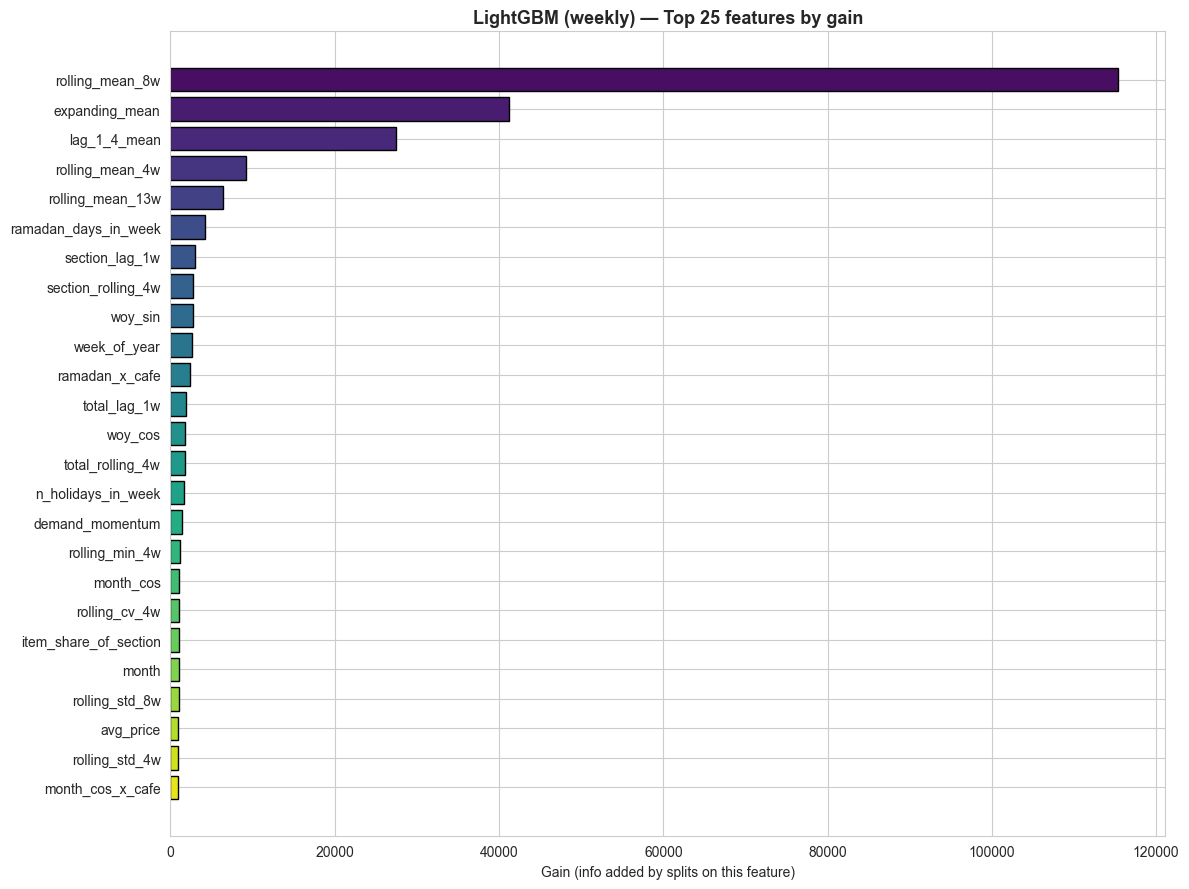


Saved: lightgbm_weekly_feature_importance.csv


In [ ]:
# LightGBM exposes 'split' (count) and 'gain' (info) importance
importance_split = pd.Series(
    model.feature_importance(importance_type='split'),
    index=feature_cols
).sort_values(ascending=False)

importance_gain = pd.Series(
    model.feature_importance(importance_type='gain'),
    index=feature_cols
).sort_values(ascending=False)

importance_df = pd.DataFrame({
    'gain': importance_gain,
    'split': importance_split,
}).fillna(0).sort_values('gain', ascending=False)

top_30 = importance_df.head(30)
print("=" * 70)
print("TOP 30 FEATURES BY GAIN")
print("=" * 70)
print(top_30[['gain', 'split']].round(2).to_string())

fig, ax = plt.subplots(figsize=(12, 9))
top_25 = importance_df.head(25)
colors = sns.color_palette('viridis', len(top_25))
ax.barh(range(len(top_25)), top_25['gain'], color=colors, edgecolor='black')
ax.set_yticks(range(len(top_25)))
ax.set_yticklabels(top_25.index, fontsize=10)
ax.set_xlabel('Gain (info added by splits on this feature)')
ax.set_title('LightGBM (weekly) — Top 25 features by gain')
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('lightgbm_weekly_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

importance_df.to_csv(os.path.join(DATASETS_DIR, 'lightgbm_weekly_feature_importance.csv'))
print(f"\nSaved: lightgbm_weekly_feature_importance.csv")


## 14. Sample predictions across volume tiers


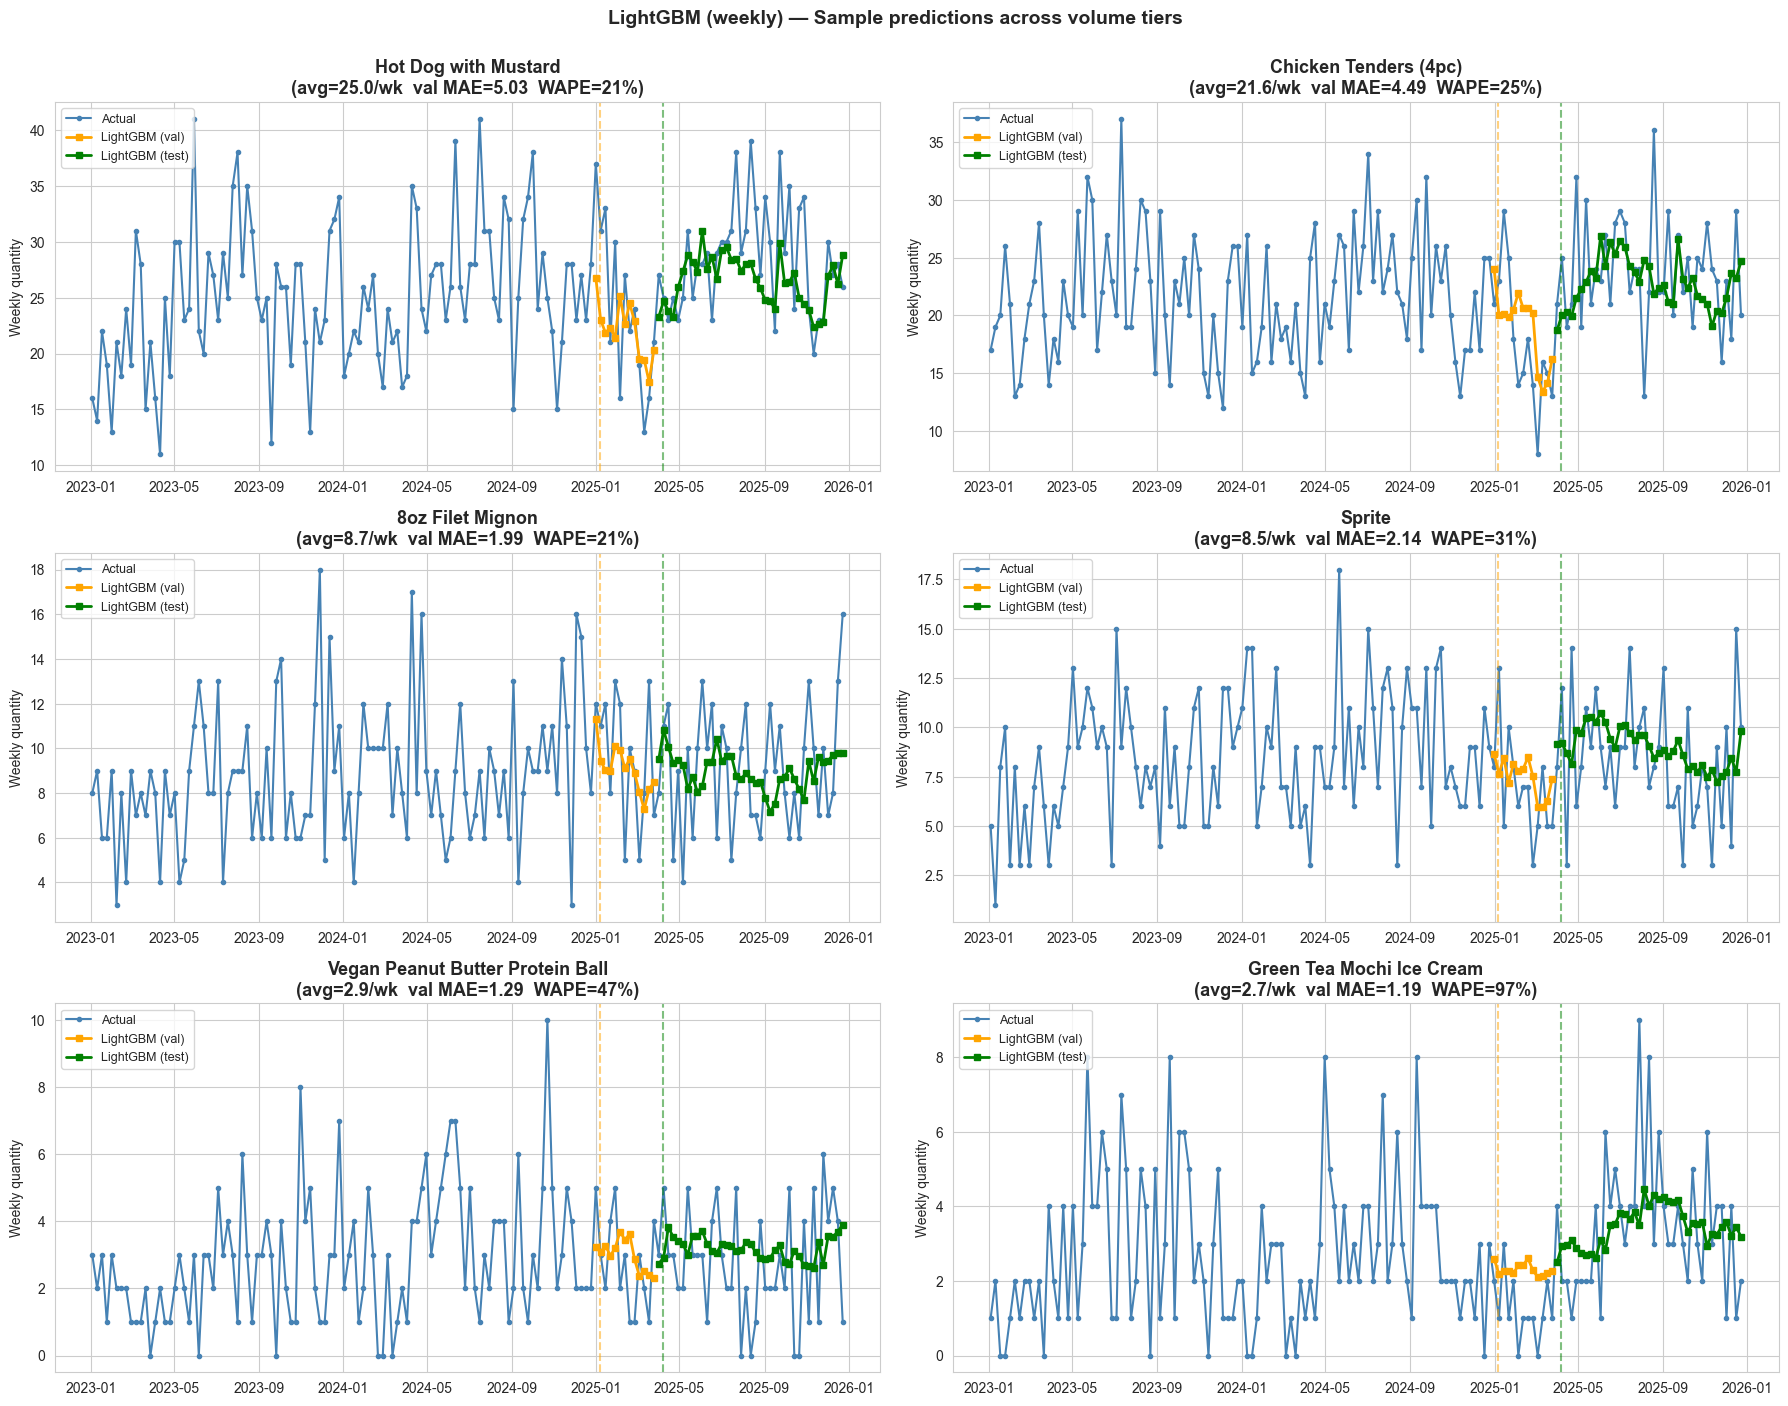

In [ ]:
sample_items = []
sample_items += list(item_volume.head(2).index)
mid_idx = len(item_volume) // 2
sample_items += list(item_volume.iloc[mid_idx-1:mid_idx+1].index)
sample_items += list(item_volume.tail(2).index)

fig, axes = plt.subplots(3, 2, figsize=(18, 14))
axes = axes.flatten()

for ax, item in zip(axes, sample_items):
    item_full = df_orig[df_orig['item_name'] == item].set_index('week_start')['quantity']
    ax.plot(item_full.index, item_full.values, color='steelblue', linewidth=1.5,
            marker='o', markersize=3, label='Actual')

    item_pred = predictions_df[predictions_df['item_name'] == item].copy()
    item_pred['ds'] = pd.to_datetime(item_pred['ds'])

    for split, color in [('val', 'orange'), ('test', 'green')]:
        sp = item_pred[item_pred['split'] == split].sort_values('ds')
        ax.plot(sp['ds'], sp['predicted'], color=color, linewidth=2,
                marker='s', markersize=4, label=f'LightGBM ({split})')

    ax.axvline(pd.Timestamp('2025-01-06'), color='orange', linestyle='--', alpha=0.5)
    ax.axvline(pd.Timestamp('2025-04-07'), color='green', linestyle='--', alpha=0.5)

    avg = item_volume[item]
    val_metrics = metrics_df[(metrics_df['item_name']==item) & (metrics_df['split']=='val')]
    if len(val_metrics) > 0:
        val_mae = val_metrics['mae'].values[0]
        val_wape = val_metrics['wape'].values[0]
        ax.set_title(f'{item}\n(avg={avg:.1f}/wk  val MAE={val_mae:.2f}  WAPE={val_wape*100:.0f}%)')
    ax.legend(loc='upper left', fontsize=9)
    ax.set_ylabel('Weekly quantity')

plt.suptitle('LightGBM (weekly) — Sample predictions across volume tiers',
             fontsize=14, fontweight='bold', y=1.001)
plt.tight_layout()
plt.savefig('lightgbm_weekly_sample_predictions.png', dpi=150, bbox_inches='tight')
plt.show()


## 15. Residual diagnostics


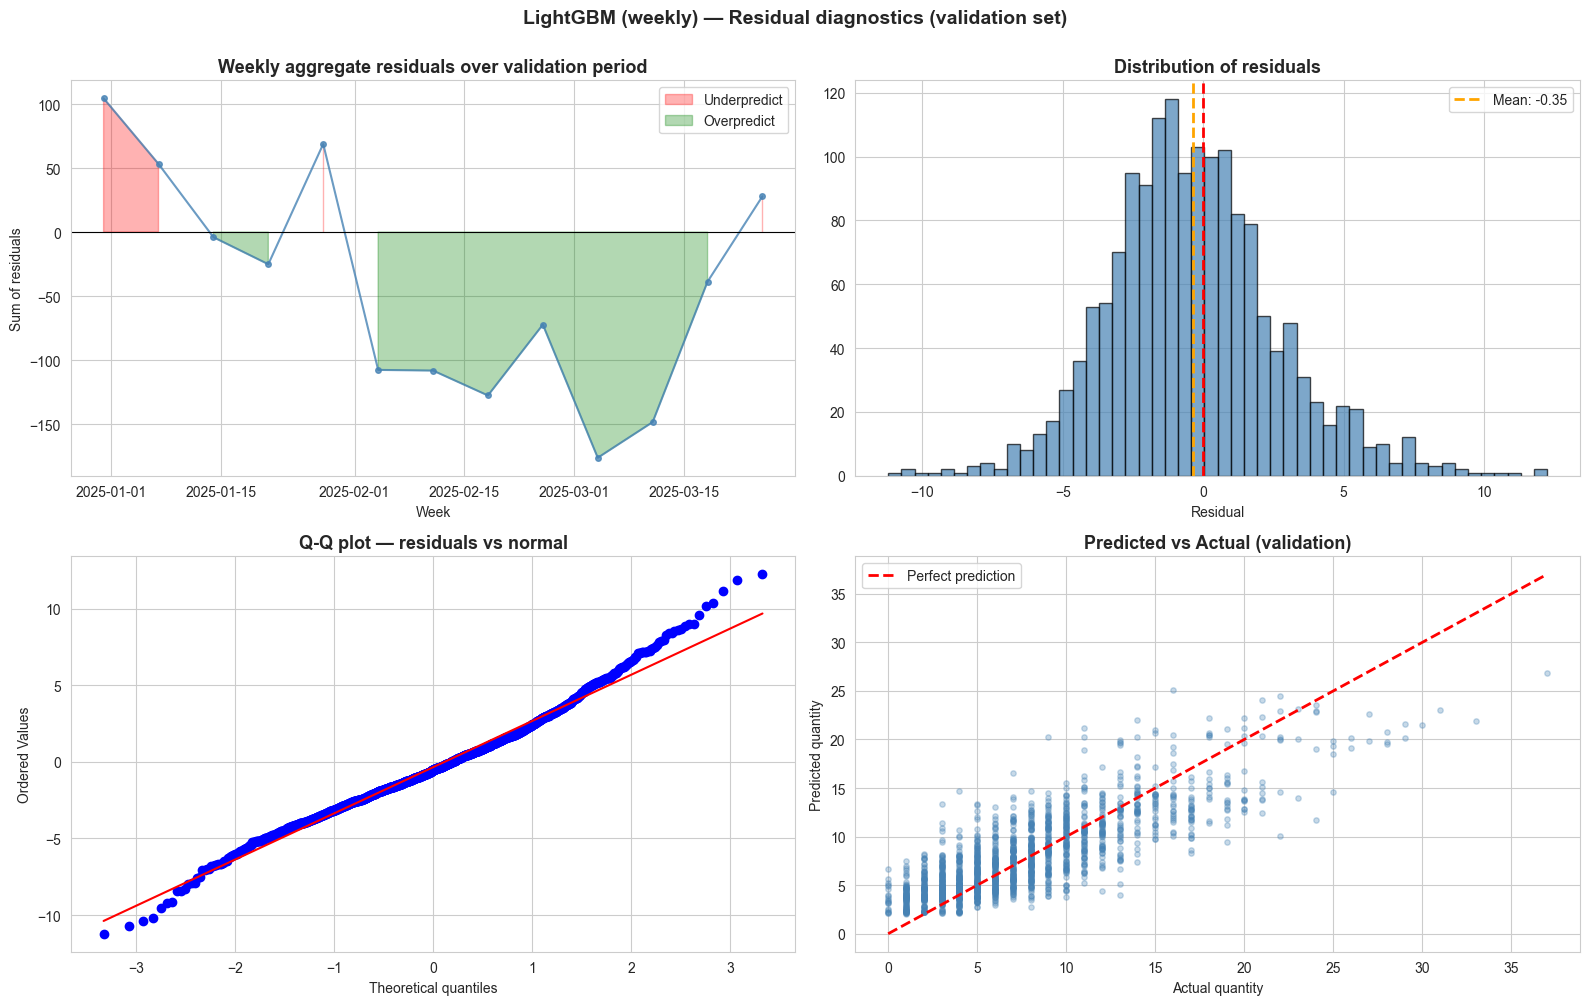


Residual statistics (validation):
  Mean:     -0.3490
  Median:   -0.5318
  Std:      3.0296
  Skewness: 0.3657
  Kurtosis: 0.9565


In [ ]:
val_pred = predictions_df[predictions_df['split'] == 'val'].copy()
val_pred['residual'] = val_pred['actual'] - val_pred['predicted']
val_pred['ds'] = pd.to_datetime(val_pred['ds'])

weekly_residuals = val_pred.groupby('ds').agg(sum_residual=('residual', 'sum')).reset_index()

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

ax = axes[0, 0]
ax.plot(weekly_residuals['ds'], weekly_residuals['sum_residual'],
        color='steelblue', linewidth=1.5, alpha=0.8, marker='o', markersize=4)
ax.axhline(0, color='black', linewidth=0.8)
ax.fill_between(weekly_residuals['ds'], 0, weekly_residuals['sum_residual'],
                where=(weekly_residuals['sum_residual'] > 0), alpha=0.3, color='red', label='Underpredict')
ax.fill_between(weekly_residuals['ds'], 0, weekly_residuals['sum_residual'],
                where=(weekly_residuals['sum_residual'] <= 0), alpha=0.3, color='green', label='Overpredict')
ax.set_title('Weekly aggregate residuals over validation period')
ax.set_xlabel('Week'); ax.set_ylabel('Sum of residuals'); ax.legend()

ax = axes[0, 1]
sample_res = val_pred['residual'].sample(min(5000, len(val_pred)), random_state=42)
ax.hist(sample_res, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
ax.axvline(0, color='red', linestyle='--', linewidth=2)
ax.axvline(sample_res.mean(), color='orange', linestyle='--', linewidth=2,
           label=f'Mean: {sample_res.mean():.2f}')
ax.set_title('Distribution of residuals'); ax.set_xlabel('Residual'); ax.legend()

ax = axes[1, 0]
stats.probplot(sample_res, dist='norm', plot=ax)
ax.set_title('Q-Q plot — residuals vs normal')

ax = axes[1, 1]
sample_ap = val_pred.sample(min(3000, len(val_pred)), random_state=42)
ax.scatter(sample_ap['actual'], sample_ap['predicted'], alpha=0.3, s=15, color='steelblue')
max_val = max(sample_ap['actual'].max(), sample_ap['predicted'].max())
ax.plot([0, max_val], [0, max_val], 'r--', linewidth=2, label='Perfect prediction')
ax.set_xlabel('Actual quantity'); ax.set_ylabel('Predicted quantity')
ax.set_title('Predicted vs Actual (validation)'); ax.legend()

plt.suptitle('LightGBM (weekly) — Residual diagnostics (validation set)',
             fontsize=14, fontweight='bold', y=1.001)
plt.tight_layout()
plt.savefig('lightgbm_weekly_residuals.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nResidual statistics (validation):")
print(f"  Mean:     {val_pred['residual'].mean():.4f}")
print(f"  Median:   {val_pred['residual'].median():.4f}")
print(f"  Std:      {val_pred['residual'].std():.4f}")
print(f"  Skewness: {stats.skew(val_pred['residual']):.4f}")
print(f"  Kurtosis: {stats.kurtosis(val_pred['residual']):.4f}")


## 16. Error breakdown by week-of-year and month


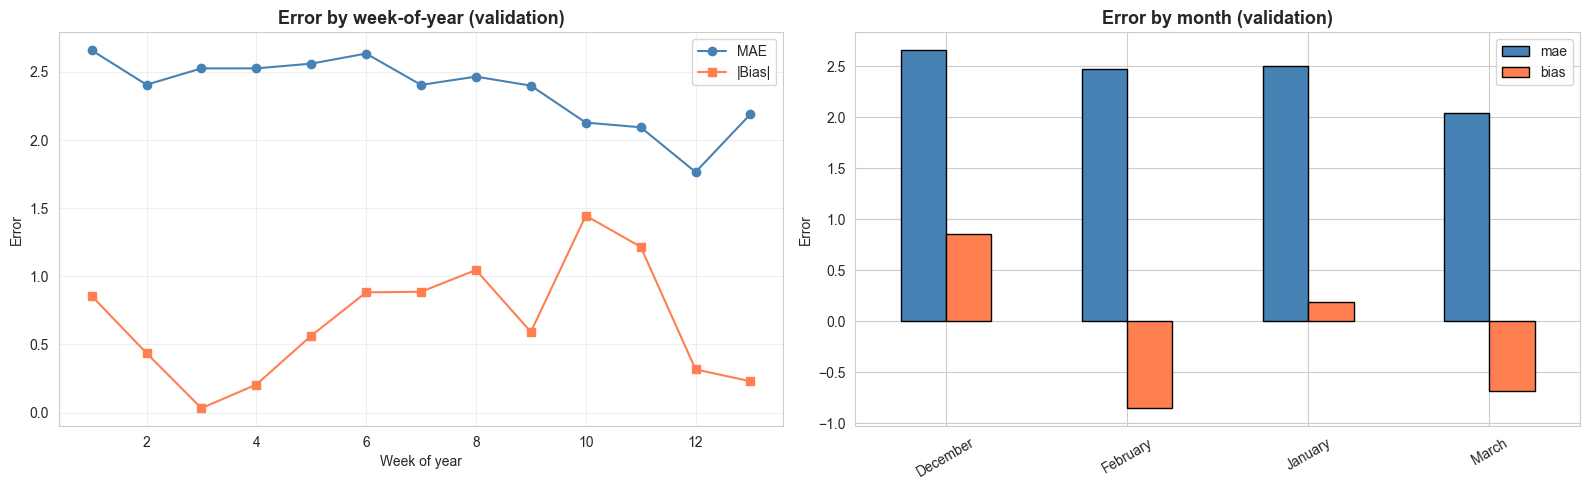

Week-of-year (top 10 weeks by MAE):
                mae   bias
week_of_year              
1             2.659  0.857
6             2.635 -0.883
5             2.561  0.565
4             2.526 -0.206
3             2.526 -0.033
8             2.465 -1.046
2             2.406  0.437
7             2.405 -0.887
9             2.399 -0.592
13            2.190  0.230

Month:
            mae   bias
month                 
December  2.659  0.857
February  2.476 -0.852
January   2.505  0.191
March     2.044 -0.687


In [ ]:
val_pred['week_of_year'] = val_pred['ds'].dt.isocalendar().week
val_pred['month'] = val_pred['ds'].dt.month_name()
val_pred['abs_error'] = np.abs(val_pred['residual'])

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
woy_err = val_pred.groupby('week_of_year').agg(mae=('abs_error','mean'), bias=('residual','mean'))
ax.plot(woy_err.index, woy_err['mae'], marker='o', color='steelblue', label='MAE')
ax.plot(woy_err.index, woy_err['bias'].abs(), marker='s', color='coral', label='|Bias|')
ax.set_title('Error by week-of-year (validation)')
ax.set_xlabel('Week of year'); ax.set_ylabel('Error')
ax.legend(); ax.grid(alpha=0.3)

ax = axes[1]
month_err = val_pred.groupby('month').agg(mae=('abs_error','mean'), bias=('residual','mean'))
month_err.plot(kind='bar', ax=ax, color=['steelblue', 'coral'], edgecolor='black')
ax.set_title('Error by month (validation)')
ax.set_ylabel('Error'); ax.set_xlabel(''); ax.tick_params(axis='x', rotation=30); ax.legend()

plt.tight_layout()
plt.savefig('lightgbm_weekly_error_breakdown.png', dpi=150, bbox_inches='tight')
plt.show()

print("Week-of-year (top 10 weeks by MAE):")
print(woy_err.sort_values('mae', ascending=False).head(10).round(3).to_string())
print("\nMonth:")
print(month_err.round(3).to_string())


## 17. Per-item WAPE distribution and outliers


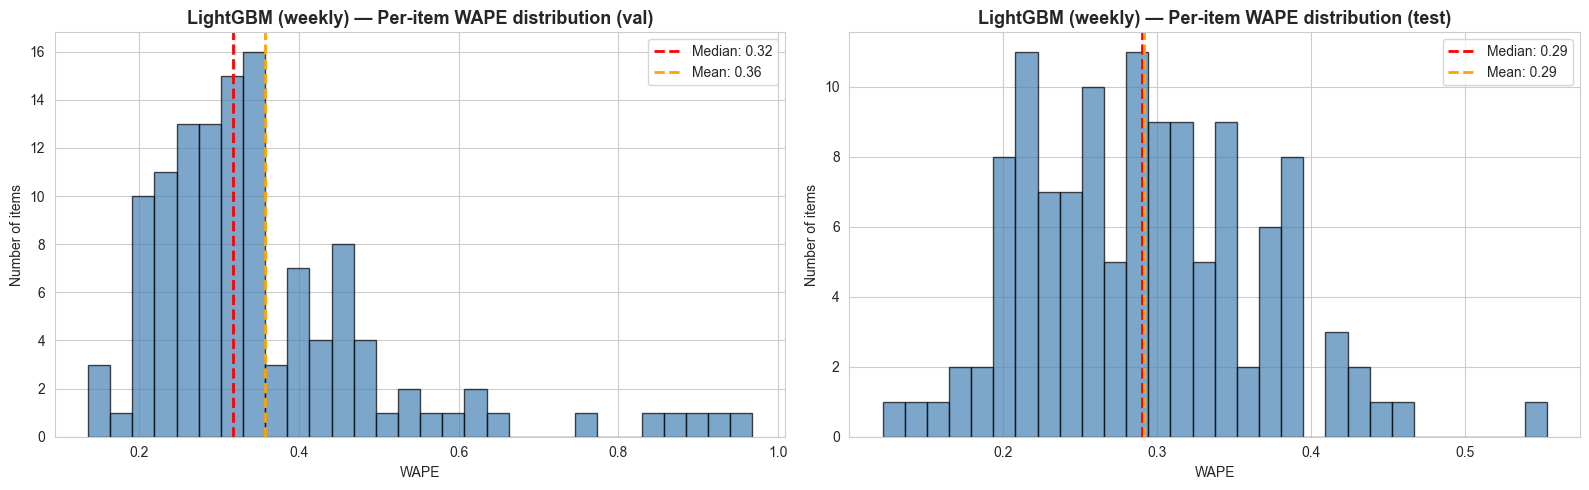

BEST 10 items (lowest WAPE on val):
                        item_name    mae   wape      r2
               Philly Cheesesteak 1.9958 0.1358  0.4856
                      Dragon Roll 1.4632 0.1420 -0.2937
               Fettuccine Alfredo 2.1010 0.1607  0.5013
                 Margherita Pizza 1.5878 0.1651  0.2574
                 Almond Croissant 1.4772 0.1920  0.7028
                  Spicy Tuna Roll 2.1012 0.1924 -0.2007
Breakfast Sandwich (Egg & Cheese) 2.2113 0.1929  0.6507
                  Chicken Burrito 2.5693 0.2000 -0.1462
                         Horchata 0.9475 0.2019 -0.1753
              Bacon Double Burger 3.5749 0.2038  0.0861

WORST 10 items (highest WAPE on val):
                      item_name    mae   wape      r2
      Green Tea Mochi Ice Cream 1.1906 0.9674 -1.8270
                  Caprese Salad 2.2307 0.9355 -0.6002
              Vanilla Milkshake 2.3452 0.8967 -0.3257
                  Sapporo Draft 2.3902 0.8631 -0.5271
                   Lemon Gelato 1.4403 

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, split in zip(axes, ['val', 'test']):
    split_metrics = metrics_df[metrics_df['split'] == split]
    wape_clipped = split_metrics['wape'].clip(upper=3)

    ax.hist(wape_clipped, bins=30, color='steelblue', edgecolor='black', alpha=0.7)
    ax.axvline(wape_clipped.median(), color='red', linestyle='--', linewidth=2,
               label=f'Median: {wape_clipped.median():.2f}')
    ax.axvline(wape_clipped.mean(), color='orange', linestyle='--', linewidth=2,
               label=f'Mean: {wape_clipped.mean():.2f}')
    ax.set_title(f'LightGBM (weekly) — Per-item WAPE distribution ({split})')
    ax.set_xlabel('WAPE'); ax.set_ylabel('Number of items'); ax.legend()

plt.tight_layout()
plt.savefig('lightgbm_weekly_wape_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("=" * 70)
print("BEST 10 items (lowest WAPE on val):")
print("=" * 70)
print(metrics_df[metrics_df['split']=='val'].nsmallest(10, 'wape')[['item_name', 'mae', 'wape', 'r2']].to_string(index=False, float_format='%.4f'))

print("\n" + "=" * 70)
print("WORST 10 items (highest WAPE on val):")
print("=" * 70)
print(metrics_df[metrics_df['split']=='val'].nlargest(10, 'wape')[['item_name', 'mae', 'wape', 'r2']].to_string(index=False, float_format='%.4f'))


## 18. Save model for FastAPI


In [ ]:
model_path = os.path.join(MODELS_DIR, 'model.txt')
model.save_model(model_path, num_iteration=best_iter)

manifest = {
    'model_type': 'lightgbm_weekly_global',
    'granularity': 'weekly',
    'n_items': len(items),
    'n_features': len(feature_cols),
    'feature_names': feature_cols,
    'target': target_col,
    'best_iteration': int(best_iter),
    'best_score': float(best_score),
    'training_time_seconds': training_time,
    'encoding_maps': encoding_maps,
    'sections': sorted(df_orig['section'].unique().tolist()),
    'categories': sorted(df_orig['category'].unique().tolist()),
    'items': sorted(items),
    'split_dates': {
        'train_end': '2024-12-30',
        'val_end': '2025-03-31',
    },
}

with open(os.path.join(MODELS_DIR, 'manifest.json'), 'w') as f:
    json.dump(manifest, f, indent=2, default=str)

print("=" * 60)
print("FASTAPI DEPLOYMENT ARTIFACTS")
print("=" * 60)
print(f"\n🚀 Model: {model_path}")
print(f"   Size: {os.path.getsize(model_path) / 1024:.1f} KB")
print(f"\n📋 Manifest: {os.path.join(MODELS_DIR, 'manifest.json')}")


FASTAPI DEPLOYMENT ARTIFACTS

🚀 Model: ../../models/lightgbm\model.txt
   Size: 962.8 KB

📋 Manifest: ../../models/lightgbm\manifest.json


## 19. FastAPI usage example

```python
import lightgbm as lgb
import numpy as np
import json

# Load once at startup
model = lgb.Booster(model_file='models/lightgbm_weekly/model.txt')
with open('models/lightgbm_weekly/manifest.json') as f:
    manifest = json.load(f)

def predict_weekly_demand(features_dict: dict) -> float:
    x = np.array([features_dict[c] for c in manifest['feature_names']]).reshape(1, -1)
    pred = model.predict(x)[0]
    return max(0, float(pred))
```


## 20. Save predictions, metrics, and summary


In [ ]:
output_cols = ['ds', 'item_name', 'actual', 'predicted', 'split']
predictions_df[output_cols].to_csv(os.path.join(DATASETS_DIR, 'lightgbm_weekly_predictions.csv'), index=False)

metrics_df.to_csv(os.path.join(DATASETS_DIR, 'lightgbm_weekly_metrics.csv'), index=False)

summary = {
    'model': 'lightgbm_weekly',
    'model_type': 'global (one model for all 122 items)',
    'granularity': 'weekly',
    'n_items': len(items),
    'n_features': len(feature_cols),
    'training_time_seconds': training_time,
    'best_iteration': int(best_iter),
    'overall_metrics': {},
    'per_section_metrics': {},
    'per_volume_tier_metrics': {},
    'baseline_comparison': {},
    'top_features': importance_df.head(20).to_dict('index'),
}

for split in ['val', 'test']:
    sp = predictions_df[predictions_df['split'] == split]
    summary['overall_metrics'][split] = {
        k: float(v) for k, v in compute_metrics(sp['actual'].values, sp['predicted'].values).items()
    }

for split in ['val', 'test']:
    summary['per_section_metrics'][split] = {}
    for sec in section_results['section'].unique():
        row = section_results[(section_results['section']==sec) & (section_results['split']==split)]
        if len(row) > 0:
            summary['per_section_metrics'][split][sec] = {
                'mae': float(row['mae'].values[0]),
                'wape': float(row['wape'].values[0]),
                'r2': float(row['r2'].values[0]),
            }

for split in ['val', 'test']:
    summary['per_volume_tier_metrics'][split] = {}
    for tier in tier_order:
        row = tier_results[(tier_results['volume_tier']==tier) & (tier_results['split']==split)]
        if len(row) > 0:
            summary['per_volume_tier_metrics'][split][tier] = {
                'mae': float(row['mae'].values[0]),
                'wape': float(row['wape'].values[0]),
                'r2': float(row['r2'].values[0]),
            }

for _, row in comparison_df.iterrows():
    key = f"{row['Model']}_{row['Split']}"
    summary['baseline_comparison'][key] = {
        'mae': float(row['MAE']),
        'wape': float(row['WAPE']),
        'r2': float(row['R²']),
    }

with open(os.path.join(DATASETS_DIR, 'lightgbm_weekly_summary.json'), 'w') as f:
    json.dump(summary, f, indent=2, default=str)

print("=" * 60)
print("ALL ARTIFACTS SAVED")
print("=" * 60)
print(f"\n📊 For comparison notebook (05c):")
print(f"  {DATASETS_DIR}/lightgbm_weekly_predictions.csv")
print(f"  {DATASETS_DIR}/lightgbm_weekly_metrics.csv")
print(f"  {DATASETS_DIR}/lightgbm_weekly_summary.json")
print(f"  {DATASETS_DIR}/lightgbm_weekly_feature_importance.csv")
print(f"\n🚀 For FastAPI:")
print(f"  {MODELS_DIR}/model.txt")
print(f"  {MODELS_DIR}/manifest.json")


ALL ARTIFACTS SAVED

📊 For comparison notebook (05c):
  ../../datasets/lightgbm_weekly_predictions.csv
  ../../datasets/lightgbm_weekly_metrics.csv
  ../../datasets/lightgbm_weekly_summary.json
  ../../datasets/lightgbm_weekly_feature_importance.csv

🚀 For FastAPI:
  ../../models/lightgbm/model.txt
  ../../models/lightgbm/manifest.json


In [ ]:
print(f"\n{'='*60}")
print("LIGHTGBM WEEKLY GLOBAL MODEL — COMPLETE")
print(f"{'='*60}")
print(f"\nKey deliverables:")
print(f"  ✓ 1 global model trained on {len(items)} items × {len(feature_cols)} features")
print(f"  ✓ Predictions for val + test splits")
print(f"  ✓ Live training loss curves")
print(f"  ✓ Feature importance — gain + split count")
print(f"  ✓ Per-section + per-tier breakdowns")
print(f"  ✓ Sample predictions across volume tiers")
print(f"  ✓ Residual diagnostics + Q-Q + scatter")
print(f"  ✓ Error breakdown by week-of-year + month")
print(f"  ✓ FastAPI deployment artifacts")
print(f"\nVal WAPE: {summary['overall_metrics']['val']['wape']:.4f}")
print(f"Val R²:   {summary['overall_metrics']['val']['r2']:+.4f}")
print(f"\nNext: 05c_ml_comparison_weekly.ipynb (XGBoost vs LightGBM head-to-head)")



LIGHTGBM WEEKLY GLOBAL MODEL — COMPLETE

Key deliverables:
  ✓ 1 global model trained on 122 items × 84 features
  ✓ Predictions for val + test splits
  ✓ Live training loss curves
  ✓ Feature importance — gain + split count
  ✓ Per-section + per-tier breakdowns
  ✓ Sample predictions across volume tiers
  ✓ Residual diagnostics + Q-Q + scatter
  ✓ Error breakdown by week-of-year + month
  ✓ FastAPI deployment artifacts

Val WAPE: 0.3061
Val R²:   +0.6614

Next: 05c_ml_comparison_weekly.ipynb (XGBoost vs LightGBM head-to-head)
